# Multi-Stage Attack Detection Using Random Forest (Baseline)

## Recreating the IDS framework from *"Multi-stage Attack Detection and Prediction Using GNN"*

**Paper:** Friji et al. — 3-stage IDS inspired by Lockheed Martin's Cyber Kill Chain  
**This notebook:** Random Forest baseline with **stratified global IP-split**

### Design:
1. **3-stage CKC mapping** per Figure 3
2. **Stratified global IP-split** — 20% of unique src_ips from each stage → test set (ensures every stage has samples in both train & test)
3. **3 binary classifiers** (Stage_i vs Other)
4. **`src_ip_bytes` removed** per paper
5. Stage 3 prediction feasibility study with **temporal (time-based) split**

---
## 0. Library Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


---
## 1. Applying Timestamp to Dataset

Mengambil kolom `ts` dari file-file original untuk ditempelkan ke `train_test_network.csv` berdasarkan 5-Tuple identifier.

In [2]:
import glob
import os
from tqdm import tqdm

# ── 1.1 Load dataset target ─────────────────────────────────
print("Loading train_test dataset...")
df_target = pd.read_csv('train_test_network.csv')

# ── 1.2 Path ke folder dataset asli ─────────────────────────
folder_path = r'C:\Users\62811\Desktop\TA apasih\Processed_Network_dataset'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

# ── 1.3 Identifier unik untuk join (5-Tuple + attack type) ──
join_cols = ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'type']
target_time_col = 'ts'

# ── 1.4 Ekstrak timestamp dari semua file original ──────────
timestamp_mapping = {}

print(f"Mengekstrak {target_time_col} dari {len(all_files)} file original...")
for file in tqdm(all_files):
    try:
        df_orig = pd.read_csv(file, usecols=join_cols + [target_time_col])
        df_orig = df_orig.drop_duplicates(subset=join_cols)
        keys = zip(*[df_orig[c] for c in join_cols])
        timestamp_mapping.update(dict(zip(keys, df_orig[target_time_col])))
    except ValueError:
        print(f"Skipping {os.path.basename(file)} (kolom tidak cocok)")
        continue

# ── 1.5 Map timestamp ke dataset target ─────────────────────
print("Mapping timestamp ke train_test_network.csv...")
target_keys = zip(*[df_target[c] for c in join_cols])
df_target['timestamp'] = [timestamp_mapping.get(k, pd.NaT) for k in target_keys]

# ── 1.6 Evaluasi & Save ─────────────────────────────────────
missing_ts = df_target['timestamp'].isna().sum()
total_rows = len(df_target)

print("\n" + "=" * 50)
print(f"Selesai! Berhasil mapping {total_rows - missing_ts} dari {total_rows} baris.")
if missing_ts > 0:
    print(f"WARNING: Ada {missing_ts} baris yang ga nemu timestampnya.")

output_name = 'train_test_network_with_ts.csv'
df_target.to_csv(output_name, index=False)
print(f"Data tersimpan sebagai: {output_name}")

Loading train_test dataset...
Mengekstrak ts dari 23 file original...


100%|██████████| 23/23 [01:31<00:00,  3.96s/it]


Mapping timestamp ke train_test_network.csv...

Selesai! Berhasil mapping 211043 dari 211043 baris.
Data tersimpan sebagai: train_test_network_with_ts.csv


---
## 2. Feature Engineering — Time Delta

Menghitung jeda waktu (`time_delta`) antar koneksi dari IP sumber yang sama, lalu membuang kolom `timestamp` mentah untuk menghindari data leakage.

In [48]:
# ── 2.1 Load data yang sudah ada timestamp ───────────────────
print("Loading data...")
df = pd.read_csv('train_test_network.csv')

Loading data...


---
## 3. Dataset Overview

In [50]:
print(f"Dataset shape: {df.shape}")
print(f"\nAttack type distribution:")
print(df['type'].value_counts())

Dataset shape: (170591, 48)

Attack type distribution:
normal        96395
scanning      23702
injection     16310
xss           15231
dos           14547
ddos           2047
password       1034
ransomware      886
mitm            300
backdoor        139
Name: type, dtype: int64


---
## 4. Stage Mapping (per Figure 3 — Cyber Kill Chain)

| Stage | CKC Phase | ToN IoT Attacks |
|-------|-----------|-----------------| 
| **Stage 1** — Reconnaissance | Reconnaissance | scanning |
| **Stage 2** — Privilege Escalation | Delivery + Exploitation | xss, ddos, dos, injection, mitm, password |
| **Stage 3** — Access Exploitation | Installation + C2 + Actions | backdoor, ransomware |

In [51]:
STAGE_MAP = {
    'normal': 0,
    'scanning': 1,
    'xss': 2, 'ddos': 2, 'dos': 2, 'injection': 2, 'mitm': 2, 'password': 2,
    'backdoor': 3, 'ransomware': 3,
}

df['stage'] = df['type'].map(STAGE_MAP)
assert df['stage'].isna().sum() == 0

print("Stage Distribution:")
print(df['stage'].value_counts().sort_index())
for s in sorted(df['stage'].unique()):
    print(f"  Stage {s}: {list(df[df['stage']==s]['type'].unique())}")

Stage Distribution:
0    96395
1    23702
2    49469
3     1025
Name: stage, dtype: int64
  Stage 0: ['normal']
  Stage 1: ['scanning']
  Stage 2: ['dos', 'injection', 'ddos', 'password', 'xss', 'mitm']
  Stage 3: ['ransomware', 'backdoor']


---
## 5. Attack Chain Analysis (dst_ip across stages)

Menganalisis apakah ada IP tujuan yang diserang secara berurutan melewati Stage 1 → 2 → 3 (full Cyber Kill Chain).

In [53]:
# ── 5.1 Himpunan dst_ip per stage ────────────────────────────
dst_s1 = set(df[df['stage']==1]['dst_ip'].unique())
dst_s2 = set(df[df['stage']==2]['dst_ip'].unique())
dst_s3 = set(df[df['stage']==3]['dst_ip'].unique())

print("Destination IPs targeted per stage:")
print(f"  Stage 1: {len(dst_s1)} | Stage 2: {len(dst_s2)} | Stage 3: {len(dst_s3)}")

# ── 5.2 Irisan antar stage ───────────────────────────────────
dst_s1_and_s2 = dst_s1 & dst_s2
print(f"\nIPs hit by BOTH S1 & S2:  {len(dst_s1_and_s2)}")
print(f"  Also hit by S3: {len(dst_s1_and_s2 & dst_s3)}")
print(f"  NOT hit by S3:  {len(dst_s1_and_s2 - dst_s3)}")

print(f"\nIPs with S2 (no S1) then S3: {len((dst_s2 - dst_s1) & dst_s3)}")
print(f"IPs with S3 only:            {len(dst_s3 - dst_s1 - dst_s2)}")

# ── 5.3 Key targets breakdown ───────────────────────────────
all_attacked = sorted(dst_s1 | dst_s2 | dst_s3)
rows = []
for ip in all_attacked:
    s1 = len(df[(df['dst_ip']==ip) & (df['stage']==1)])
    s2 = len(df[(df['dst_ip']==ip) & (df['stage']==2)])
    s3 = len(df[(df['dst_ip']==ip) & (df['stage']==3)])
    if s1 > 0 or s3 > 0:
        rows.append({'dst_ip': ip, 'S1': s1, 'S2': s2, 'S3': s3})

print(f"\nKey targets (with S1 or S3 flows):")
print(pd.DataFrame(rows).sort_values('S3', ascending=False).to_string(index=False))
print(f"\n* 0 IPs follow the full S1->S2->S3 chain in this dataset")

Destination IPs targeted per stage:
  Stage 1: 46 | Stage 2: 161 | Stage 3: 13

IPs hit by BOTH S1 & S2:  38
  Also hit by S3: 5
  NOT hit by S3:  33

IPs with S2 (no S1) then S3: 3
IPs with S3 only:            4

Key targets (with S1 or S3 flows):
         dst_ip    S1  S2  S3
  192.168.1.193   200 128 508
   192.168.1.33   200   0 335
     121.0.0.42     0   0  49
  103.38.120.36     0  23  48
  34.230.157.88     1   9  26
    192.168.1.1   200 300  18
    13.55.50.68     0   0   9
   192.168.1.37     0   0   9
  52.11.124.117     1  14   8
  203.14.129.10     0   0   5
192.168.159.152     0  24   4
  34.236.82.205     0   5   4
    192.168.1.6     2   7   2
   192.168.1.79   200 104   0
255.255.255.255     4  24   0
203.122.222.157    35   2   0
 216.58.200.110     6  26   0
  101.119.11.11    64 300   0
 34.223.203.249     2   6   0
 34.209.222.186     3   4   0
 34.212.119.231     1   5   0
   34.215.51.80    22   7   0
   192.168.1.46    70   0   0
   52.32.141.83     7   6   0
 

---
## 6. Feature Preprocessing

Menentukan kolom-kolom yang akan di-drop sebelum training (identifier, string, label, dan `src_ip_bytes` sesuai paper).

In [54]:
DROP_COLS = [
    # ── Identifier / String columns ──
    'src_ip', 'dst_ip', 'src_port', 'dst_port',
    'dns_query', 'http_uri', 'http_user_agent',
    'ssl_subject', 'ssl_issuer', 'weird_addl',
    'dns_rejected', 'ssl_established', 'ssl_resumed',
    'weird_notice', 'dns_AA', 'dns_RD', 'dns_RA',
    'ssl_version', 'ssl_cipher',
    'http_trans_depth', 'http_method', 'http_version',
    'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name',
    # ── Label / Target columns ──
    'type', 'label', 'stage',
    # ── Paper: superficial separator ──
    'src_ip_bytes', 'ts'
]

remaining = [c for c in df.columns if c not in DROP_COLS]
print(f"Features kept ({len(remaining)}): {remaining}")

Features kept (15): ['proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_referrer', 'sequence_type']


---
## 7. Stratified Global IP-Split

**Strategy:** Untuk setiap attack stage, ambil ~20% unique `src_ip` beserta seluruh flow-nya ke test set.  
Volume-Aware Whale Filtering digunakan agar IP "raksasa" (yang flow-nya sendiri sudah melebihi kuota test) tidak membuat split timpang.

In [55]:
rng = np.random.RandomState(42)
test_ips = set()
test_ratio = 0.2

print("Volume-Aware Split with Whale Filtering:")
for s in [1, 2, 3]:
    stage_flows = df[df['stage'] == s]
    total_stage_flows = len(stage_flows)
    target_test_flows = int(test_ratio * total_stage_flows)

    ip_counts = stage_flows['src_ip'].value_counts().reset_index()
    ip_counts.columns = ['src_ip', 'flow_count']

    # Whale Filtering: IP raksasa wajib masuk train
    small_fishes = ip_counts[ip_counts['flow_count'] <= target_test_flows]
    whales = ip_counts[ip_counts['flow_count'] > target_test_flows]

    shuffled_ips = small_fishes.sample(frac=1, random_state=rng).reset_index(drop=True)

    current_test_flows = 0
    selected_ips = []

    for _, row in shuffled_ips.iterrows():
        if current_test_flows + row['flow_count'] <= target_test_flows * 1.1:
            selected_ips.append(row['src_ip'])
            current_test_flows += row['flow_count']
        if current_test_flows >= target_test_flows * 0.9:
            break

    # Fallback
    if len(selected_ips) == 0 and len(small_fishes) > 0:
        selected_ips.append(small_fishes.iloc[0]['src_ip'])
        current_test_flows += small_fishes.iloc[0]['flow_count']

    test_ips.update(selected_ips)
    print(f"  Stage {s}: Target ~{target_test_flows} flows | "
          f"Paus dilempar ke Train: {len(whales)} IP | "
          f"Selected test IPs: {len(selected_ips)} ({current_test_flows} flows)")

# ── Handle Stage 0 (Normal) ─────────────────────────────────
all_attack_ips = set(df[df['stage'] != 0]['src_ip'].unique())
normal_flows = df[df['stage'] == 0]
pure_normal_flows = normal_flows[~normal_flows['src_ip'].isin(all_attack_ips)]

total_normal_flows = len(pure_normal_flows)
target_normal_test_flows = int(test_ratio * total_normal_flows)

normal_ip_counts = pure_normal_flows['src_ip'].value_counts().reset_index()
normal_ip_counts.columns = ['src_ip', 'flow_count']

small_normal = normal_ip_counts[normal_ip_counts['flow_count'] <= target_normal_test_flows]
shuffled_normal = small_normal.sample(frac=1, random_state=rng).reset_index(drop=True)

current_normal_test_flows = 0
selected_normal_ips = []

for _, row in shuffled_normal.iterrows():
    if current_normal_test_flows + row['flow_count'] <= target_normal_test_flows * 1.1:
        selected_normal_ips.append(row['src_ip'])
        current_normal_test_flows += row['flow_count']
    if current_normal_test_flows >= target_normal_test_flows * 0.9:
        break

if len(selected_normal_ips) == 0 and len(small_normal) > 0:
    selected_normal_ips.append(small_normal.iloc[0]['src_ip'])

test_ips.update(selected_normal_ips)
print(f"  Normal-only: Target ~{target_normal_test_flows} flows | Selected test IPs: {len(selected_normal_ips)}")

# ── Eksekusi Split ───────────────────────────────────────────
TRAIN_IPS = set(df['src_ip'].unique()) - test_ips
TEST_IPS = test_ips

print(f"\nGlobal split: Train={len(TRAIN_IPS)} IPs, Test={len(TEST_IPS)} IPs, Overlap={len(TRAIN_IPS & TEST_IPS)}")

df_train = df[df['src_ip'].isin(TRAIN_IPS)].copy()
df_test = df[df['src_ip'].isin(TEST_IPS)].copy()

print(f"Train flows: {len(df_train)} | Test flows: {len(df_test)}")
print(f"\nStage distribution:")
for s in [0, 1, 2, 3]:
    tr = (df_train['stage']==s).sum()
    te = (df_test['stage']==s).sum()
    print(f"  Stage {s}: train={tr:>6}, test={te:>6}")

Volume-Aware Split with Whale Filtering:
  Stage 1: Target ~4740 flows | Paus dilempar ke Train: 1 IP | Selected test IPs: 5 (4353 flows)
  Stage 2: Target ~9893 flows | Paus dilempar ke Train: 2 IP | Selected test IPs: 10 (5843 flows)
  Stage 3: Target ~205 flows | Paus dilempar ke Train: 3 IP | Selected test IPs: 3 (14 flows)
  Normal-only: Target ~16602 flows | Selected test IPs: 4

Global split: Train=70 IPs, Test=17 IPs, Overlap=0
Train flows: 139301 | Test flows: 31290

Stage distribution:
  Stage 0: train= 76576, test= 19819
  Stage 1: train= 18415, test=  5287
  Stage 2: train= 43626, test=  5843
  Stage 3: train=   684, test=   341


---
## 8. Helper Functions

Fungsi `prepare_Xy` untuk menyiapkan fitur & label per stage, dan `evaluate_stage` untuk evaluasi binary classifier.

In [56]:
def prepare_Xy(train_data, test_data, stage_num):
    """Menyiapkan X dan y untuk binary classification (stage_num vs Other)."""
    y_train = (train_data['stage'] == stage_num).astype(int)
    y_test = (test_data['stage'] == stage_num).astype(int)

    drop = [c for c in DROP_COLS if c in train_data.columns]
    X_train = train_data.drop(columns=drop, errors='ignore')
    X_test = test_data.drop(columns=drop, errors='ignore')

    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    return X_train, X_test, y_train, y_test


def evaluate_stage(y_true, y_pred, stage_name):
    """Evaluasi binary classifier: F1, Precision, Recall, FPR, Confusion Matrix."""
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"\n{'='*50}")
    print(f"{stage_name}")
    print(f"{'='*50}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"FPR:       {fpr:.4f}")
    print(f"Confusion Matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    return {'f1': f1, 'precision': precision, 'recall': recall, 'fpr': fpr, 'cm': cm}


def plot_rf_learning_curve(X_train, y_train, X_test, y_test, stage_name, max_estimators=200, step=10):
    """Plot OOB error dan test accuracy Random Forest selama penambahan n_estimators.
    
    Random Forest bukan model iteratif seperti neural network, sehingga tidak memiliki
    loss curve per epoch. Sebagai gantinya, kita plot OOB error dan test accuracy 
    sebagai fungsi dari jumlah trees untuk melihat konvergensi model.
    """
    oob_errors = []
    test_accuracies = []
    n_estimators_range = list(range(step, max_estimators + 1, step))
    
    rf_curve = RandomForestClassifier(
        n_estimators=step, max_depth=20,
        min_samples_split=5, min_samples_leaf=2,
        class_weight='balanced', random_state=42, n_jobs=-1,
        warm_start=True, oob_score=True
    )
    
    for n_est in n_estimators_range:
        rf_curve.set_params(n_estimators=n_est)
        rf_curve.fit(X_train, y_train)
        
        oob_errors.append(1 - rf_curve.oob_score_)
        test_acc = (rf_curve.predict(X_test) == y_test).mean()
        test_accuracies.append(test_acc)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: OOB Error (proxy untuk training loss)
    ax1.plot(n_estimators_range, oob_errors, 'b-o', markersize=4, label='OOB Error')
    ax1.set_xlabel('Number of Trees')
    ax1.set_ylabel('OOB Error')
    ax1.set_title(f'{stage_name}\nOOB Error vs Number of Trees')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Test Accuracy
    ax2.plot(n_estimators_range, test_accuracies, 'g-o', markersize=4, label='Test Accuracy')
    ax2.set_xlabel('Number of Trees')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{stage_name}\nTest Accuracy vs Number of Trees')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'learning_curve_{stage_name.lower().replace(" ", "_").replace(":", "")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"  Final OOB Error: {oob_errors[-1]:.4f} | Final Test Accuracy: {test_accuracies[-1]:.4f}")

print("Functions defined.")

Functions defined.


---
## 9. Stage 1 Detector — Reconnaissance

In [57]:
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = prepare_Xy(df_train, df_test, stage_num=1)

print(f"Train: {len(X_train_s1)} flows (stage1={y_train_s1.sum()}, other={(y_train_s1==0).sum()})")
print(f"Test:  {len(X_test_s1)} flows (stage1={y_test_s1.sum()}, other={(y_test_s1==0).sum()})")
print(f"Features: {X_train_s1.shape[1]}")

rf_s1 = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)

print("\nTraining Stage 1...")
rf_s1.fit(X_train_s1, y_train_s1)
y_pred_s1 = rf_s1.predict(X_test_s1)

results_s1 = evaluate_stage(y_test_s1, y_pred_s1, "Stage 1: Reconnaissance")
print(f"\n{classification_report(y_test_s1, y_pred_s1, target_names=['Other','Stage 1'])}")

Train: 139301 flows (stage1=18415, other=120886)
Test:  31290 flows (stage1=5287, other=26003)
Features: 1893

Training Stage 1...

Stage 1: Reconnaissance
F1-Score:  0.5140
Precision: 0.7302
Recall:    0.3966
FPR:       0.0298
Confusion Matrix:  TN=25228  FP=775  FN=3190  TP=2097

              precision    recall  f1-score   support

       Other       0.89      0.97      0.93     26003
     Stage 1       0.73      0.40      0.51      5287

    accuracy                           0.87     31290
   macro avg       0.81      0.68      0.72     31290
weighted avg       0.86      0.87      0.86     31290



---
## 10. Stage 2 Detector — Privilege Escalation

In [58]:
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = prepare_Xy(df_train, df_test, stage_num=2)

print(f"Train: {len(X_train_s2)} flows (stage2={y_train_s2.sum()}, other={(y_train_s2==0).sum()})")
print(f"Test:  {len(X_test_s2)} flows (stage2={y_test_s2.sum()}, other={(y_test_s2==0).sum()})")
print(f"Features: {X_train_s2.shape[1]}")

rf_s2 = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)

print("\nTraining Stage 2...")
rf_s2.fit(X_train_s2, y_train_s2)
y_pred_s2 = rf_s2.predict(X_test_s2)

results_s2 = evaluate_stage(y_test_s2, y_pred_s2, "Stage 2: Privilege Escalation")
print(f"\n{classification_report(y_test_s2, y_pred_s2, target_names=['Other','Stage 2'])}")

Train: 139301 flows (stage2=43626, other=95675)
Test:  31290 flows (stage2=5843, other=25447)
Features: 1893

Training Stage 2...

Stage 2: Privilege Escalation
F1-Score:  0.8013
Precision: 0.9434
Recall:    0.6964
FPR:       0.0096
Confusion Matrix:  TN=25203  FP=244  FN=1774  TP=4069

              precision    recall  f1-score   support

       Other       0.93      0.99      0.96     25447
     Stage 2       0.94      0.70      0.80      5843

    accuracy                           0.94     31290
   macro avg       0.94      0.84      0.88     31290
weighted avg       0.94      0.94      0.93     31290



### 10.1 Learning Curve — Stage 2

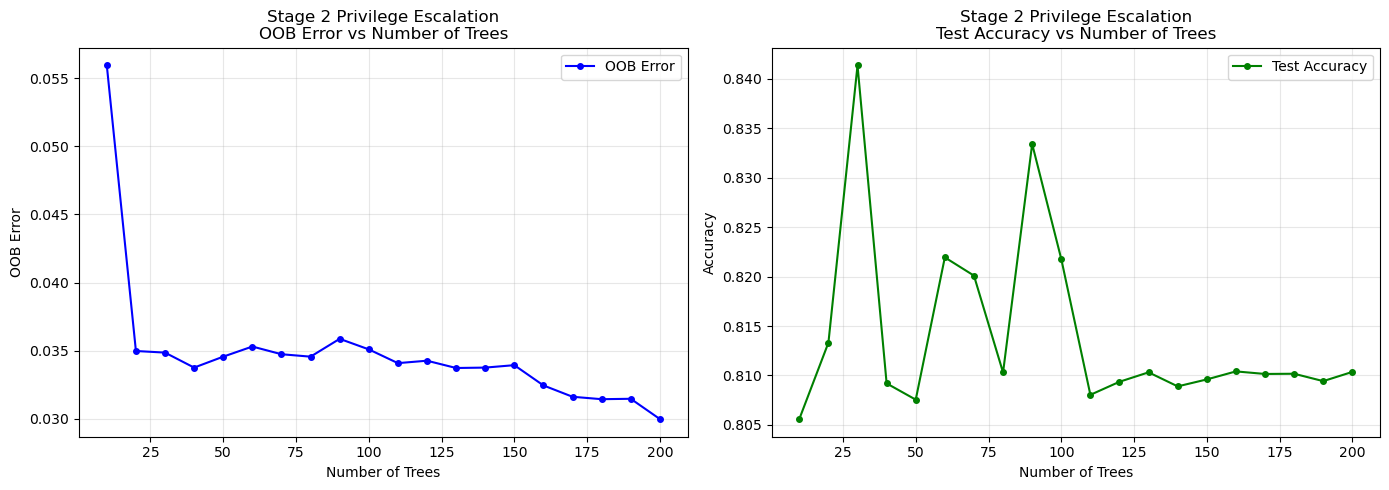

  Final OOB Error: 0.0300 | Final Test Accuracy: 0.8104


In [ ]:
plot_rf_learning_curve(X_train_s2, y_train_s2, X_test_s2, y_test_s2, "Stage 2 Privilege Escalation")

---
## 11. Stage 3 Detector — Access Exploitation

In [59]:
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = prepare_Xy(df_train, df_test, stage_num=3)

print(f"Train: {len(X_train_s3)} flows (stage3={y_train_s3.sum()}, other={(y_train_s3==0).sum()})")
print(f"Test:  {len(X_test_s3)} flows (stage3={y_test_s3.sum()}, other={(y_test_s3==0).sum()})")
print(f"Features: {X_train_s3.shape[1]}")

rf_s3 = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)

print("\nTraining Stage 3...")
rf_s3.fit(X_train_s3, y_train_s3)
y_pred_s3 = rf_s3.predict(X_test_s3)

results_s3 = evaluate_stage(y_test_s3, y_pred_s3, "Stage 3: Access Exploitation")
print(f"\n{classification_report(y_test_s3, y_pred_s3, target_names=['Other','Stage 3'])}")

Train: 139301 flows (stage3=684, other=138617)
Test:  31290 flows (stage3=341, other=30949)
Features: 1893

Training Stage 3...

Stage 3: Access Exploitation
F1-Score:  0.2745
Precision: 0.1598
Recall:    0.9736
FPR:       0.0564
Confusion Matrix:  TN=29203  FP=1746  FN=9  TP=332

              precision    recall  f1-score   support

       Other       1.00      0.94      0.97     30949
     Stage 3       0.16      0.97      0.27       341

    accuracy                           0.94     31290
   macro avg       0.58      0.96      0.62     31290
weighted avg       0.99      0.94      0.96     31290



### 11.1 Learning Curve — Stage 3

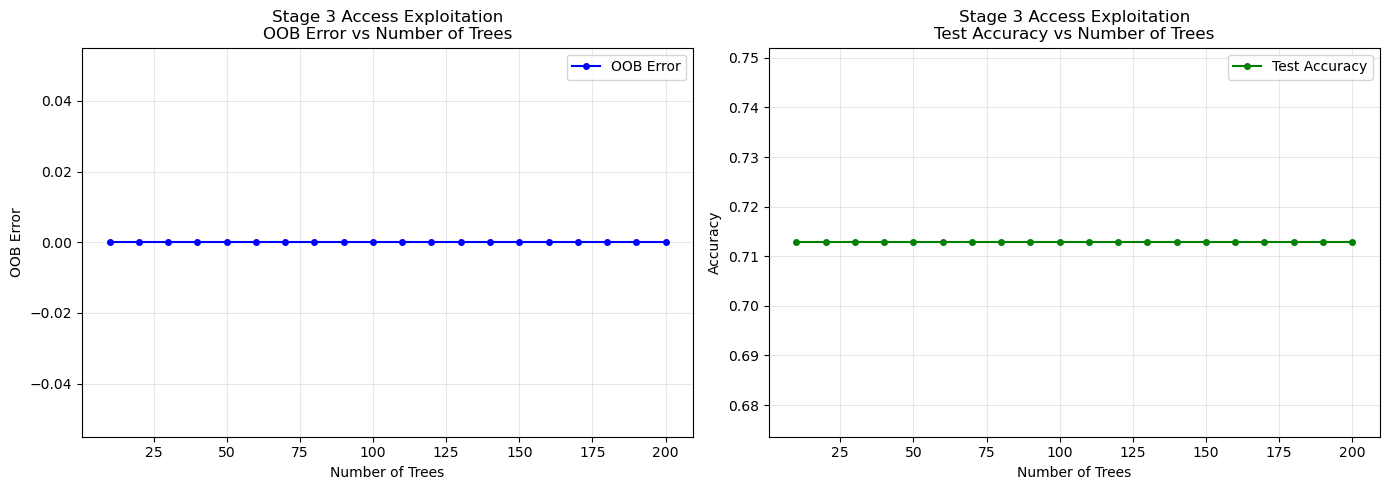

  Final OOB Error: 0.0000 | Final Test Accuracy: 0.7128


In [ ]:
plot_rf_learning_curve(X_train_s3, y_train_s3, X_test_s3, y_test_s3, "Stage 3 Access Exploitation")

---
## 12. Results Summary — Comparison with Paper

In [60]:
paper_bench = {
    'Stage 1': {'f1': 0.976, 'precision': 0.978, 'recall': 0.974, 'fpr': 0.021},
    'Stage 2': {'f1': 0.905, 'precision': 0.882, 'recall': 0.930, 'fpr': 0.123},
    'Stage 3': {'f1': 0.864, 'precision': 0.808, 'recall': 0.929, 'fpr': 0.220},
}

paper_prop = {
    'Stage 1': {'f1': 0.995, 'precision': 0.993, 'recall': 0.998, 'fpr': 0.007},
    'Stage 2': {'f1': 0.930, 'precision': 0.880, 'recall': 0.980, 'fpr': 0.134},
    'Stage 3': {'f1': 0.893, 'precision': 0.824, 'recall': 0.973, 'fpr': 0.207},
}

our = {'Stage 1': results_s1, 'Stage 2': results_s2, 'Stage 3': results_s3}

print("=" * 80)
print("COMPARISON TABLE")
print("=" * 80)
print(f"{'Model':<30} {'F1':>8} {'Prec':>8} {'Recall':>8} {'FPR':>8}")
print("-" * 80)

for stage in ['Stage 1', 'Stage 2', 'Stage 3']:
    o = our[stage]; b = paper_bench[stage]; p = paper_prop[stage]
    print(f"\n--- {stage} ---")
    print(f"{'Our RF (stratified split)':<30} {o['f1']:>8.4f} {o['precision']:>8.4f} {o['recall']:>8.4f} {o['fpr']:>8.4f}")
    print(f"{'Paper Benchmark (RF)':<30} {b['f1']:>8.4f} {b['precision']:>8.4f} {b['recall']:>8.4f} {b['fpr']:>8.4f}")
    print(f"{'Paper Proposed (GNN+RF)':<30} {p['f1']:>8.4f} {p['precision']:>8.4f} {p['recall']:>8.4f} {p['fpr']:>8.4f}")

avg_o = np.mean([our[s]['f1'] for s in our])
avg_b = np.mean([paper_bench[s]['f1'] for s in paper_bench])
avg_p = np.mean([paper_prop[s]['f1'] for s in paper_prop])
print(f"\n{'='*80}")
print(f"Avg F1 -> Ours: {avg_o:.4f} | Paper Bench: {avg_b:.4f} | Paper Proposed: {avg_p:.4f}")

COMPARISON TABLE
Model                                F1     Prec   Recall      FPR
--------------------------------------------------------------------------------

--- Stage 1 ---
Our RF (stratified split)        0.5140   0.7302   0.3966   0.0298
Paper Benchmark (RF)             0.9760   0.9780   0.9740   0.0210
Paper Proposed (GNN+RF)          0.9950   0.9930   0.9980   0.0070

--- Stage 2 ---
Our RF (stratified split)        0.8013   0.9434   0.6964   0.0096
Paper Benchmark (RF)             0.9050   0.8820   0.9300   0.1230
Paper Proposed (GNN+RF)          0.9300   0.8800   0.9800   0.1340

--- Stage 3 ---
Our RF (stratified split)        0.2745   0.1598   0.9736   0.0564
Paper Benchmark (RF)             0.8640   0.8080   0.9290   0.2200
Paper Proposed (GNN+RF)          0.8930   0.8240   0.9730   0.2070

Avg F1 -> Ours: 0.5299 | Paper Bench: 0.9150 | Paper Proposed: 0.9393


---
## 13. Confusion Matrices Visualization

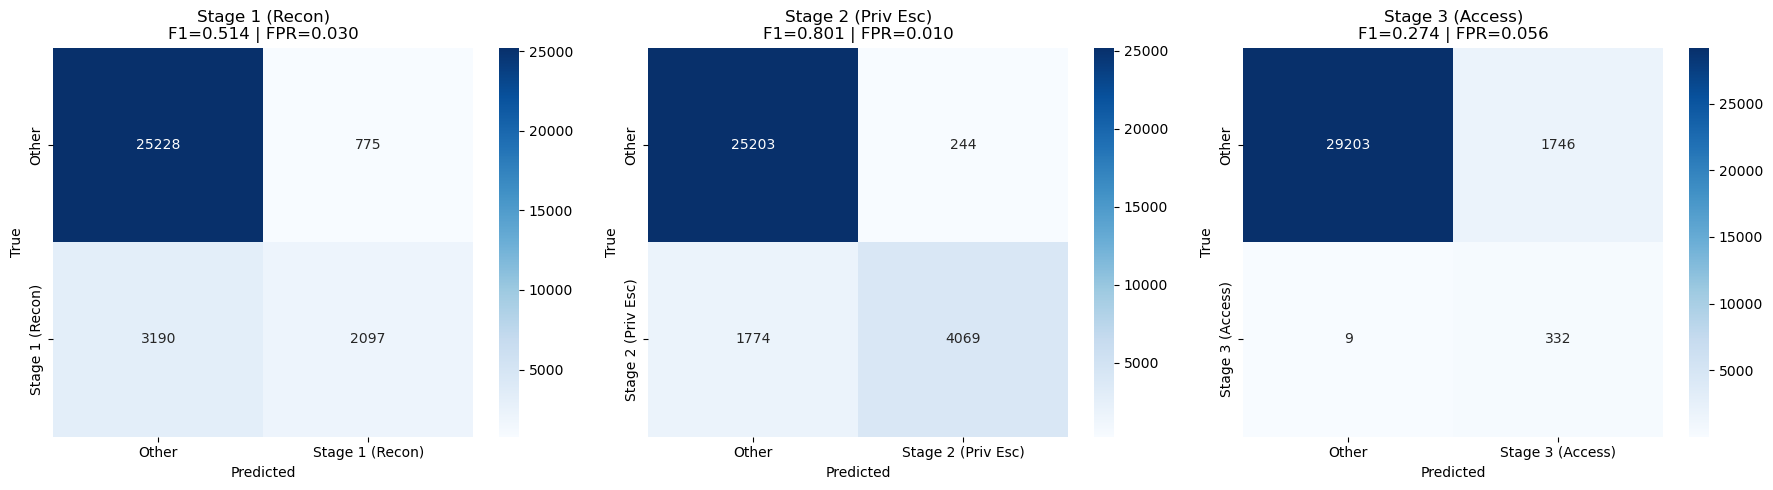

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Stage 1 (Recon)', 'Stage 2 (Priv Esc)', 'Stage 3 (Access)']
all_res = [results_s1, results_s2, results_s3]

for ax, lbl, res in zip(axes, labels, all_res):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Other', lbl], yticklabels=['Other', lbl])
    ax.set_title(f"{lbl}\nF1={res['f1']:.3f} | FPR={res['fpr']:.3f}")
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Feature Importance (Top 15 per Stage)

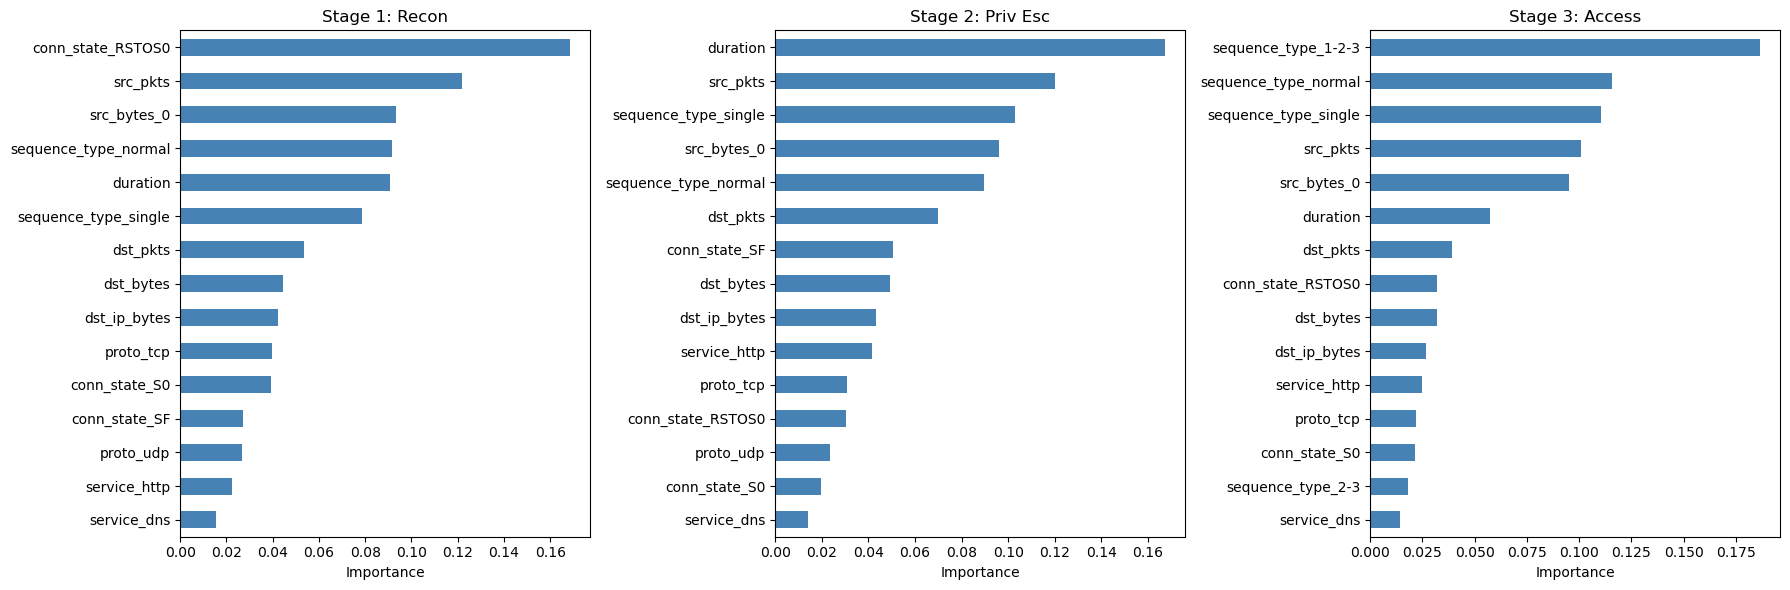

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
models = [rf_s1, rf_s2, rf_s3]
X_trains = [X_train_s1, X_train_s2, X_train_s3]
labels = ['Stage 1: Recon', 'Stage 2: Priv Esc', 'Stage 3: Access']

for ax, model, X_tr, title in zip(axes, models, X_trains, labels):
    imp = pd.Series(model.feature_importances_, index=X_tr.columns).nlargest(15)
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title); ax.set_xlabel('Importance'); ax.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

single    102328
normal     96395
1-2        28267
1-2-3       6197
2-3           64
Name: sequence_type, dtype: int64

---
## 15. Temporal (Time-Based) Split untuk AE Prediction

### Mengapa perlu Time Split?

Model AE Prediction bertujuan memprediksi **masa depan** — apakah suatu entitas (`dst_ip`) yang sudah terkena Stage 1 dan Stage 2 akan terkena Stage 3 di kemudian hari. Evaluasi model prediktif seperti ini **wajib** menggunakan pembagian temporal:

- **Train set** = event-event yang terjadi di **masa lalu** (past events)
- **Test set** = event-event yang terjadi di **masa depan** (future events)

Dengan cara ini, model benar-benar diuji pada data yang belum pernah dilihat secara kronologis, bukan hanya secara random — sehingga evaluasinya realistis dan mencerminkan skenario deployment sesungguhnya.

**Implementasi:** Data diurutkan berdasarkan `timestamp`, lalu dipotong pada persentil waktu tertentu (default 80%). Semua flow sebelum titik potong menjadi train, sisanya menjadi test.

TEMPORAL SPLIT — PAST vs FUTURE

Total flows: 211043
Timestamp range: 1970-01-01 00:00:01.554198359 → 1970-01-01 00:00:01.556549121
Cutoff time (80th percentile): 1970-01-01 00:00:01.556340949

Train (past events):   168943 flows (1970-01-01 00:00:01.554198359 → 1970-01-01 00:00:01.556340949)
Test  (future events): 42100 flows (1970-01-01 00:00:01.556340950 → 1970-01-01 00:00:01.556549121)

Stage distribution (Temporal Split):
  Stage 0: train= 49654, test=   346
  Stage 1: train= 20000, test=     0
  Stage 2: train= 99289, test=  1754
  Stage 3: train=     0, test= 40000


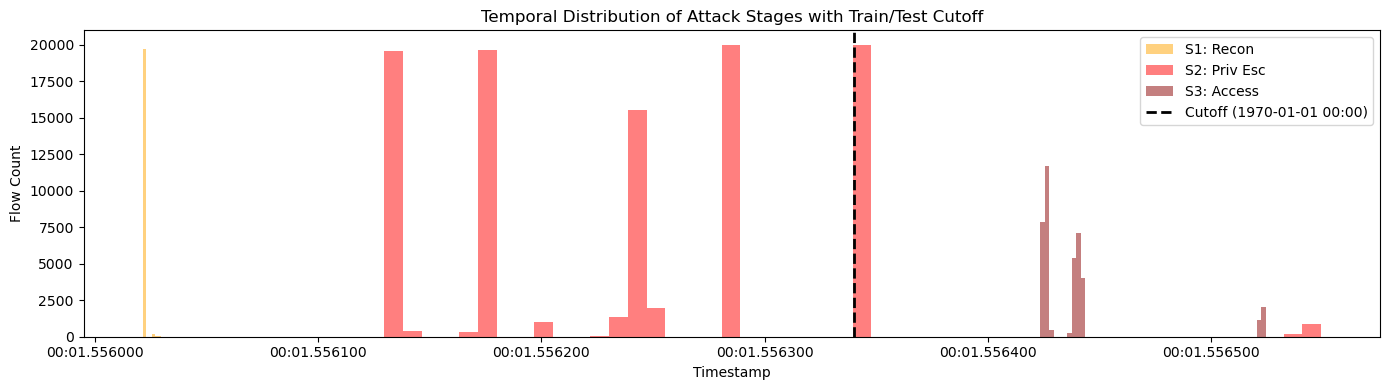

In [63]:
# ── 15.1 Reload data dengan timestamp (belum di-drop) ────────
print("=" * 60)
print("TEMPORAL SPLIT — PAST vs FUTURE")
print("=" * 60)

df_ts = pd.read_csv('train_test_network_with_ts.csv')
df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'], errors='coerce')
df_ts = df_ts.dropna(subset=['timestamp'])

# ── 15.2 Stage mapping (sama seperti sebelumnya) ────────────
df_ts['stage'] = df_ts['type'].map(STAGE_MAP)
assert df_ts['stage'].isna().sum() == 0

# ── 15.3 Hitung time_delta SEBELUM split (agar konsisten) ───
df_ts = df_ts.sort_values(by=['src_ip', 'timestamp'])
df_ts['time_delta'] = df_ts.groupby('src_ip')['timestamp'].diff().dt.total_seconds()
df_ts['time_delta'] = df_ts['time_delta'].fillna(0)

# ── 15.4 Tentukan titik potong temporal ──────────────────────
TEMPORAL_SPLIT_RATIO = 0.8
all_timestamps = df_ts['timestamp'].sort_values()
cutoff_idx = int(len(all_timestamps) * TEMPORAL_SPLIT_RATIO)
cutoff_time = all_timestamps.iloc[cutoff_idx]

print(f"\nTotal flows: {len(df_ts)}")
print(f"Timestamp range: {all_timestamps.iloc[0]} → {all_timestamps.iloc[-1]}")
print(f"Cutoff time (80th percentile): {cutoff_time}")

# ── 15.5 Split berdasarkan waktu ─────────────────────────────
df_train_ts = df_ts[df_ts['timestamp'] <= cutoff_time].copy()
df_test_ts = df_ts[df_ts['timestamp'] > cutoff_time].copy()

print(f"\nTrain (past events):   {len(df_train_ts)} flows ({df_train_ts['timestamp'].min()} → {df_train_ts['timestamp'].max()})")
print(f"Test  (future events): {len(df_test_ts)} flows ({df_test_ts['timestamp'].min()} → {df_test_ts['timestamp'].max()})")

print(f"\nStage distribution (Temporal Split):")
for s in [0, 1, 2, 3]:
    tr = (df_train_ts['stage']==s).sum()
    te = (df_test_ts['stage']==s).sum()
    print(f"  Stage {s}: train={tr:>6}, test={te:>6}")

# ── 15.6 Visualisasi distribusi temporal ─────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
for s, color, label in [(1, 'orange', 'S1: Recon'), (2, 'red', 'S2: Priv Esc'), (3, 'darkred', 'S3: Access')]:
    stage_times = df_ts[df_ts['stage']==s]['timestamp']
    ax.hist(stage_times, bins=50, alpha=0.5, color=color, label=label)

ax.axvline(x=cutoff_time, color='black', linestyle='--', linewidth=2, label=f'Cutoff ({cutoff_time.strftime("%Y-%m-%d %H:%M")})')
ax.set_xlabel('Timestamp'); ax.set_ylabel('Flow Count')
ax.set_title('Temporal Distribution of Attack Stages with Train/Test Cutoff')
ax.legend()
plt.tight_layout()
plt.savefig('temporal_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 16. Stage 3 Prediction — Building the AE Dataset (Temporal Split)

Membangun dataset untuk Access Exploitation prediction sesuai paper, kali ini menggunakan **temporal split**:
- **Train:** probabilitas S1 & S2 dari flow-flow di masa lalu (sebelum cutoff)
- **Test:** probabilitas S1 & S2 dari flow-flow di masa depan (setelah cutoff)

Ini memastikan model benar-benar memprediksi kejadian masa depan, bukan sekedar generalisasi dari data acak.

In [ ]:
print("=" * 60)
print("MEMBANGUN DATASET AE PREDICTION (TEMPORAL SPLIT)")
print("=" * 60)

# ── 16.1 Generate prediksi S1, S2, S3 pada data temporal ────
# Gunakan model RF yang sudah dilatih (rf_s1, rf_s2, rf_s3) dari IP-split
# untuk menghasilkan probabilitas pada data temporal

def add_stage_predictions(df_in):
    """Tambahkan kolom prediksi dan probabilitas S1/S2/S3 ke dataframe."""
    df_out = df_in.copy()
    
    # Prepare features (sama seperti prepare_Xy tapi tanpa split)
    drop = [c for c in DROP_COLS + ['timestamp'] if c in df_out.columns]
    X = df_out.drop(columns=drop, errors='ignore')
    X = pd.get_dummies(X, drop_first=True)
    
    # Align dengan training features
    X, _ = X.align(pd.DataFrame(columns=X_train_s1.columns), join='right', axis=1, fill_value=0)
    
    # Prediksi
    df_out['pred_s1'] = rf_s1.predict(X)
    df_out['pred_s2'] = rf_s2.predict(X)
    df_out['pred_s3'] = rf_s3.predict(X)
    df_out['prob_s1'] = rf_s1.predict_proba(X)[:, 1]
    df_out['prob_s2'] = rf_s2.predict_proba(X)[:, 1]
    df_out['is_s3'] = (df_out['stage'] == 3).astype(int)
    
    return df_out

print("Generating S1/S2/S3 predictions pada data temporal...")
df_train_ts_pred = add_stage_predictions(df_train_ts)
df_test_ts_pred = add_stage_predictions(df_test_ts)

print(f"Train predictions generated: {len(df_train_ts_pred)} flows")
print(f"Test predictions generated:  {len(df_test_ts_pred)} flows")

# ── 16.2 Buat AE dataset dari data temporal ──────────────────
def create_paper_ae_dataset(df_in):
    """Membuat dataset AE prediction: list probabilitas S1 & S2 per dst_ip."""
    df_sorted = df_in.sort_values(by=['dst_ip', 'timestamp'])

    print("Mengekstrak list sekuensial per entitas...")
    grouped = df_sorted.groupby('dst_ip').agg(
        s1_prob_list=('prob_s1', list),
        s2_prob_list=('prob_s2', list),
        s1_alert_count=('pred_s1', 'sum'),
        s2_alert_count=('pred_s2', 'sum'),
        actual_s3=('is_s3', lambda x: (x == 1).sum() > 0)
    ).reset_index()

    # Filter: hanya IP dengan riwayat S1 DAN S2
    paper_df = grouped[(grouped['s1_alert_count'] > 0) & (grouped['s2_alert_count'] > 0)].copy()
    paper_df['label'] = paper_df['actual_s3'].astype(int)

    return paper_df[['dst_ip', 's1_prob_list', 's2_prob_list', 'label']]

ae_train = create_paper_ae_dataset(df_train_ts_pred)
ae_test = create_paper_ae_dataset(df_test_ts_pred)

print(f"\n[HASIL FILTERING]")
print(f"AE Train Dataset (past events):   {len(ae_train)} targeted users")
print(f"AE Test Dataset  (future events): {len(ae_test)} targeted users")

print(f"\n[DISTRIBUSI LABEL TRAIN (0 = Tidak Lanjut S3, 1 = Lanjut S3)]")
print(ae_train['label'].value_counts())

print(f"\n[DISTRIBUSI LABEL TEST]")
print(ae_test['label'].value_counts())

print("\n[PREVIEW AE DATASET]")
print(ae_train.head(3))

MEMBANGUN DATASET AE PREDICTION (TEMPORAL SPLIT)
Generating S1/S2/S3 predictions pada data temporal...
Train predictions generated: 168943 flows
Test predictions generated:  42100 flows
Mengekstrak list sekuensial per entitas...
Mengekstrak list sekuensial per entitas...

[HASIL FILTERING]
AE Train Dataset (past events):   37 targeted users
AE Test Dataset  (future events): 16 targeted users

[DISTRIBUSI LABEL TRAIN (0 = Tidak Lanjut S3, 1 = Lanjut S3)]
0    37
Name: label, dtype: int64

[DISTRIBUSI LABEL TEST]
0    12
1     4
Name: label, dtype: int64

[PREVIEW AE DATASET]
           dst_ip                                       s1_prob_list  \
30  117.18.237.29  [0.7438024415817825, 0.3352107581888638, 0.743...   
37   13.107.3.128  [0.22811086832373445, 0.22811086832373445, 0.2...   
48  13.35.146.115  [0.7438024415817825, 0.32565652769584047, 0.32...   

                                         s2_prob_list  label  
30  [0.14833292610808763, 0.46238832991834505, 0.1...      0  
37  

---
## 17. RNN/LSTM Training — Stage 3 Access Exploitation Prediction

Melatih model LSTM sederhana dengan input sequence probabilitas S1 & S2 per `dst_ip` untuk memprediksi apakah IP tersebut akan terkena serangan Stage 3.

Karena menggunakan **temporal split**, model dilatih pada event masa lalu dan dievaluasi pada event masa depan — sesuai dengan skenario prediksi yang realistis.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight

print("=" * 60)
print("TRAINING RNN/LSTM UNTUK AE PREDICTION (STAGE 3)")
print("=" * 60)

# ── 17.1 Preprocessing — Pad sequences ──────────────────────
MAX_TIMESTEPS = 50

def prepare_rnn_data(df):
    """Pad sequences S1 & S2 lalu stack jadi 3D array (samples, timesteps, 2)."""
    X_s1 = pad_sequences(df['s1_prob_list'].values, maxlen=MAX_TIMESTEPS, padding='post', dtype='float32')
    X_s2 = pad_sequences(df['s2_prob_list'].values, maxlen=MAX_TIMESTEPS, padding='post', dtype='float32')
    X = np.stack((X_s1, X_s2), axis=-1)
    y = df['label'].values
    return X, y

print(f"Memproses sequence data (Max timesteps = {MAX_TIMESTEPS})...")
X_train_rnn, y_train_rnn = prepare_rnn_data(ae_train)
X_test_rnn, y_test_rnn = prepare_rnn_data(ae_test)

print(f"Shape X_train: {X_train_rnn.shape}")
print(f"Shape X_test:  {X_test_rnn.shape}")

# ── 17.2 Class weights (handle imbalanced data) ─────────────
classes = np.unique(y_train_rnn)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_rnn)
class_weight_dict = {classes[i]: weights[i] for i in range(len(classes))}
print(f"Class Weights: {class_weight_dict}")

# ── 17.3 Build LSTM architecture ────────────────────────────
model = Sequential([
    Masking(mask_value=0., input_shape=(MAX_TIMESTEPS, 2)),
    LSTM(16, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── 17.4 Training (dengan validation split untuk monitoring) ─
print("\nMulai Training...")
history = model.fit(
    X_train_rnn, y_train_rnn,
    epochs=20,
    batch_size=4,
    class_weight=class_weight_dict,
    validation_data=(X_test_rnn, y_test_rnn),
    verbose=1
)

# ── 17.5 Evaluasi ───────────────────────────────────────────
print("\n" + "=" * 50)
print("EVALUASI MODEL DI DATA TEST (FUTURE EVENTS)")
print("=" * 50)

y_pred_probs = model.predict(X_test_rnn)
y_pred_rnn = (y_pred_probs > 0.5).astype(int).flatten()

print(classification_report(y_test_rnn, y_pred_rnn, target_names=['Safe (0)', 'S3 Attack (1)'], zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test_rnn, y_pred_rnn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Safe', 'S3 Attack'], yticklabels=['Safe', 'S3 Attack'])
plt.title('RNN/LSTM Prediction (Stage 3 Access Exploitation)\n[Temporal Split: Trained on Past, Tested on Future]')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

ModuleNotFoundError: No module named 'tensorflow'

### 17.6 Training Curves — LSTM Loss & Accuracy

Grafik loss dan accuracy per epoch untuk melihat konvergensi model LSTM dan apakah terjadi overfitting (gap antara training dan validation).

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history.history['loss']) + 1)

# ── Plot Loss ────────────────────────────────────────────────
ax1.plot(epochs, history.history['loss'], 'b-o', markersize=4, label='Training Loss')
ax1.plot(epochs, history.history['val_loss'], 'r-o', markersize=4, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (Binary Crossentropy)')
ax1.set_title('LSTM — Loss per Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot Accuracy ────────────────────────────────────────────
ax2.plot(epochs, history.history['accuracy'], 'b-o', markersize=4, label='Training Accuracy')
ax2.plot(epochs, history.history['val_accuracy'], 'r-o', markersize=4, label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('LSTM — Accuracy per Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('RNN/LSTM Training Curves — Stage 3 AE Prediction (Temporal Split)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Training Loss:     {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss:   {history.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

---
## 18. Conclusion

### Results:
- 3 RF classifiers with **stratified global IP-split** (20% per-stage IPs to test)
- Every stage guaranteed to have samples in both train and test
- No cross-stage IP leakage
- **Learning curves** (OOB error & test accuracy) plotted for each RF stage detector

### AE Prediction with Temporal Split:
- **Time-based split** digunakan untuk evaluasi model prediksi Stage 3
- Train = past events (sebelum cutoff), Test = future events (setelah cutoff)
- LSTM training curves (loss & accuracy) menunjukkan konvergensi model

### Key dataset limitation:
- **0 dst_ips follow S1→S2→S3 chain** — limits CKC-based prediction
- Paper's own AE prediction also had poor results (~30 samples)

### Next steps:
1. Add GCN context-aware model
2. Stack GCN + RF with logistic regression meta-model
3. Multi-input RNN for Stage 3 prediction
4. Find dataset with actual multi-stage attack sequences